<a href="https://colab.research.google.com/github/borisbolliet/agents_lab_2026/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
!pip install langchain -q
!pip install langchain-google-genai -q
!pip install python-dotenv -q
```

In [1]:
try:
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except ImportError:
    from dotenv import load_dotenv
    import os
    load_dotenv()
    GOOGLE_API_KEY = os.environ['GOOGLE_API_KEY']

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview',
                             temperature=1.,
                             thinking_level="low",
                             google_api_key=GOOGLE_API_KEY)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


## Define a tool

In [4]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.tools import tool

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

/Users/boris/pyvenvs/py312-agents-lab-2026/lib/python3.12/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
get_weather.name

'get_weather'

In [6]:
get_weather.description

'Get current weather and optional forecast.'

In [7]:
get_weather.args_schema.model_json_schema()

{'description': 'Input for weather queries.',
 'properties': {'location': {'description': 'City name or coordinates',
   'title': 'Location',
   'type': 'string'},
  'units': {'default': 'celsius',
   'description': 'Temperature unit preference',
   'enum': ['celsius', 'fahrenheit'],
   'title': 'Units',
   'type': 'string'},
  'include_forecast': {'default': False,
   'description': 'Include 5-day forecast',
   'title': 'Include Forecast',
   'type': 'boolean'}},
 'required': ['location'],
 'title': 'WeatherInput',
 'type': 'object'}

## Invoke the tool directly

In [10]:
get_weather.invoke({"location": "Paris", "units": "fahrenheit", "include_forecast": True})

'Current weather in Paris: 72 degrees F\nNext 5 days: Sunny'

## Let the LLM call the tool

In [11]:
from langchain_core.messages import HumanMessage

llm_with_tools = llm.bind_tools([get_weather])

In [12]:
response = llm_with_tools.invoke([HumanMessage("What's the weather in Tokyo in fahrenheit?")])

In [13]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'units': 'fahrenheit', 'location': 'Tokyo'},
  'id': 'b2bb5d7e-435c-4491-95f4-e4c2ba33379e',
  'type': 'tool_call'}]

The LLM did not run the tool. It produced a `tool_call` — a name and arguments. We have to execute it.

In [14]:
call = response.tool_calls[0]
get_weather.invoke(call["args"])

'Current weather in Tokyo: 72 degrees F'

## Make an agent

An agent runs the LLM ↔ tool loop for us.

In [15]:
from langchain.tools import tool
from langchain.agents import create_agent

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def get_weather(location: str) -> str:
    """Get weather information for a location."""
    return f"Weather in {location}: Sunny, 72°F"

agent = create_agent(llm, tools=[search, get_weather])

In [16]:
result = agent.invoke(
    {"messages": [HumanMessage("What's the weather in Cambridge? Then search for fun things to do there.")]}
)

In [17]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's the weather in Cambridge? Then search for fun things to do there.
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather (e128a932-12b2-42b5-8cc0-21ba4e7f6008)
 Call ID: e128a932-12b2-42b5-8cc0-21ba4e7f6008
  Args:
    location: Cambridge, UK
  get_weather (0d3165f1-6163-426c-89f5-e44f7b690a09)
 Call ID: 0d3165f1-6163-426c-89f5-e44f7b690a09
  Args:
    location: Cambridge, MA, USA
  search (ac8adb08-f427-47dc-b184-ad4ef8bc1f40)
 Call ID: ac8adb08-f427-47dc-b184-ad4ef8bc1f40
  Args:
    query: fun things to do in Cambridge UK
  search (637f5a28-a551-46d1-95d6-561dbad18506)
 Call ID: 637f5a28-a551-46d1-95d6-561dbad18506
  Args:
    query: fun things to do in Cambridge Massachusetts
================================= Tool Message =================================
Name: get_weather

Weather in Cambridge, UK: Sunny, 72°F
============================

In [19]:
from IPython.display import Markdown                                                                                                                                          
Markdown(result["messages"][-1].text)                                                                                                                                                          

Since there are two well-known cities named Cambridge, here is the weather and some fun activities for both:

### **Cambridge, United Kingdom**
*   **Weather:** Sunny and 72°F (22°C).
*   **Fun Things to Do:**
    *   **Punting on the River Cam:** This is the quintessential Cambridge experience. You can hire a boat or take a guided tour to see the historic colleges from the water.
    *   **King’s College Chapel:** Famous for its stunning gothic architecture and choir.
    *   **The Fitzwilliam Museum:** A world-class art and antiquities museum that is free to enter.
    *   **Explore the "Backs":** Walk along the river behind the colleges for some of the best views of the historic architecture.
    *   **Botanical Garden:** A beautiful place to relax and enjoy a wide variety of plants and trees.

### **Cambridge, Massachusetts, USA**
*   **Weather:** Sunny and 72°F (22°C).
*   **Fun Things to Do:**
    *   **Explore Harvard Square:** Browse the historic bookstores, grab a coffee, and soak up the academic atmosphere.
    *   **Visit the Harvard Museums:** The Harvard Museum of Natural History (famous for the Glass Flowers) and the Harvard Art Museums are top-tier.
    *   **MIT Museum:** Perfect if you love technology, robotics, and innovation.
    *   **Walk the Charles River Esplanade:** Offers fantastic views of the Boston skyline and is a great spot for walking, jogging, or biking.
    *   **Central Square:** Known for its eclectic mix of live music venues, theaters, and a diverse range of restaurants.

**Which Cambridge were you looking for?** If you have a specific interest (like museums, food, or nature), let me know and I can give you more tailored recommendations!

## Force the tool call

So far the model *decides* whether to call a tool. Sometimes we want to force it.

We use `wrap_model_call` middleware that overrides `tool_choice` only on the first model call. After the tool runs, the second call is unconstrained — so the model can produce a final natural-language answer instead of looping forever on the same tool.

In [20]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain_core.messages import AIMessage
from typing import Callable

@wrap_model_call
def force_get_weather_first(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    if not any(isinstance(m, AIMessage) for m in request.messages):
        return handler(request.override(tool_choice="get_weather"))
    return handler(request)

agent = create_agent(llm, tools=[get_weather], middleware=[force_get_weather_first])

In [21]:
result = agent.invoke(
    {"messages": [HumanMessage("Tell me something interesting about Cambridge.")]}
)

In [22]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Tell me something interesting about Cambridge.
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather (ae8d3418-2db5-4dae-8564-858cde7bd752)
 Call ID: ae8d3418-2db5-4dae-8564-858cde7bd752
  Args:
    location: Cambridge, UK
================================= Tool Message =================================
Name: get_weather

Weather in Cambridge, UK: Sunny, 72°F
================================== Ai Message ==================================

[{'type': 'text', 'text': 'One of the most fascinating things about Cambridge is that it is the birthplace of our modern understanding of life itself.\n\nOn February 28, 1953, two scientists, **Francis Crick and James Watson**, walked into a local pub called **The Eagle** and announced that they had "discovered the secret of life." They were referring to the double-helix structure of DNA.\n\nIf you visit Cambridge 

In [23]:
Markdown(result["messages"][-1].text)                                                                                                                                                          

One of the most fascinating things about Cambridge is that it is the birthplace of our modern understanding of life itself.

On February 28, 1953, two scientists, **Francis Crick and James Watson**, walked into a local pub called **The Eagle** and announced that they had "discovered the secret of life." They were referring to the double-helix structure of DNA.

If you visit Cambridge today, you can actually go to The Eagle (which is still a functioning pub) and have a pint near the very spot where this monumental scientific breakthrough was announced to the world. There is a plaque on the outside of the building commemorating the discovery.

**A quick bonus fact:**
If you visit the city, you’ll likely see the famous "Mathematical Bridge" at Queens' College. There is a persistent urban legend that it was designed by Sir Isaac Newton without the use of a single nut or bolt—that it was held together entirely by gravity and physics. While that’s a lovely story, it’s unfortunately not true: the bridge was built over 20 years after Newton died, and it actually *does* use iron fasteners (though they were hidden by the design).

It’s a beautiful day in Cambridge right now, with sunny skies and a pleasant temperature of 72°F (22°C)—perfect weather if you wanted to go for a stroll to The Eagle!

## Same pattern in LangGraph

`create_agent` is a convenience layer on top of LangGraph. When we drop down to LangGraph we write the model node ourselves — and the same `tool_choice` trick lives directly inside it.

In [28]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

def call_model(state):
    msgs = state["messages"]
    is_first = not any(isinstance(m, AIMessage) for m in msgs)
    bound = llm.bind_tools([get_weather], tool_choice="get_weather" if is_first else None)
    return {"messages": [bound.invoke(msgs)]}

def should_continue(state):
    return "tools" if state["messages"][-1].tool_calls else END

graph = (
    StateGraph(MessagesState) # Creates a graph builder
    .add_node("model", call_model) # Registers our call_model function as a node called "model".
    .add_node("tools", ToolNode([get_weather])) # Registers the prebuilt ToolNode as "tools".
    .add_edge(START, "model") # the entry-point: when graph.invoke(...) is called, run "model" first.
    .add_conditional_edges("model", should_continue, {"tools": "tools", END: END}) # After "model" runs, call should_continue(state) and go to whatever node name it returns (or END to stop). The path_map (last argument, optional) lets the renderer see both branches.
    .add_edge("tools", "model") # after "tools" runs, always go back to "model".
    .compile()
)

result = graph.invoke({"messages": [HumanMessage("Tell me something interesting about Cambridge.")]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Tell me something interesting about Cambridge.
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather (a43803fb-0a2e-4a96-8021-5a1f844b24d1)
 Call ID: a43803fb-0a2e-4a96-8021-5a1f844b24d1
  Args:
    location: Cambridge, UK
================================= Tool Message =================================
Name: get_weather

Weather in Cambridge, UK: Sunny, 72°F
================================== Ai Message ==================================

[{'type': 'text', 'text': 'It is a beautiful, sunny 72°F (22°C) in Cambridge, UK today!\n\nIf you are looking for something interesting about the city, here is a fascinating fact that surprises many people: **Cambridge is essentially the birthplace of modern football.**\n\nIn 1848, a group of students and staff from various public schools met at Parker’s Piece (a large public park in the city) to create the "Cambri

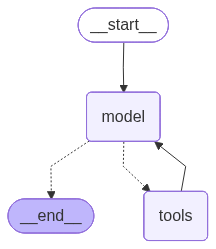

In [29]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
Markdown(result["messages"][-1].text) 

It is a beautiful, sunny 72°F (22°C) in Cambridge, UK today!

If you are looking for something interesting about the city, here is a fascinating fact that surprises many people: **Cambridge is essentially the birthplace of modern football.**

In 1848, a group of students and staff from various public schools met at Parker’s Piece (a large public park in the city) to create the "Cambridge Rules." Before this, every school had its own chaotic version of "football," and they couldn't play against each other because the rules were too different. 

The Cambridge Rules were the first to unify the game, introducing goal kicks, throw-ins, and the banning of carrying the ball with hands. These rules became the direct template for the Football Association (FA) rules written in London in 1863. So, every time you watch a professional football match anywhere in the world, you are effectively watching a sport shaped on a field in Cambridge.

***

**A few other quick "Did you know?" facts:**

*   **The "Mathematical Bridge" Myth:** There is a famous wooden bridge at Queens' College that is often called the "Mathematical Bridge." Legend has it that Isaac Newton designed it to be self-supporting without the use of a single nut or bolt. The story goes that students took it apart to see how it worked but couldn't put it back together, so they had to use bolts to hold it in place. It’s a great story, but unfortunately, it’s not true—the bridge was built in 1749, long after Newton had died, and it had bolts from the very start.
*   **The Nobel Prize Hub:** Cambridge has an incredibly high concentration of brainpower. The University of Cambridge is associated with more Nobel Prize winners than almost any other institution in the world—over 120 affiliates have won the prize across various fields.